In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
valor_amostras = 8
dataset = "dataset_com_tempo_janelamento_teste_8.csv"
df_original = pd.read_csv("dataset_com_tempo_janelamento_teste_8.csv")

def dividir_dados(caminho_arquivo, num_massflows=5):
    caminho_arquivo = Path(caminho_arquivo)
    
    if not caminho_arquivo.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {caminho_arquivo}")

    df = pd.read_csv(caminho_arquivo)
    
    massflow_cols = [f'massFlow_{i}' for i in range(1, num_massflows + 1)]  # range(1, 6) -> massFlow_1 a massFlow_5
    dados = df[massflow_cols].values.astype(np.float32)
    
    tamanho_treino = int(len(dados) * 0.75)
    treino_dados = dados[:tamanho_treino]
    validacao_dados = dados[tamanho_treino:]
    
    return {
        "x_train": torch.tensor(treino_dados),
        "x_val": torch.tensor(validacao_dados)
    }

In [23]:
class BaseModel(nn.Module):
    def __init__(self, **kwargs):
        super(BaseModel, self).__init__()
        self.model = None  # Placeholder for model architecture in subclasses
        self.optimizer = None
        self.criterion = None
        self.kwargs = kwargs

    def compile_model(self, optimizer_fn=optim.Adam, learning_rate=0.001, criterion_fn=nn.MSELoss):
        """Set up the optimizer and loss function."""
        self.optimizer = optimizer_fn(self.parameters(), lr=learning_rate)
        self.criterion = criterion_fn()
        # print("Model compiled with custom optimizer and loss function.")

    def train_model(self, x_train, y_train, loss_function, epochs=10, batch_size=32, validation_split=0.2):
        """Train the model on the provided dataset."""
        dataset_size = len(x_train)
        split = int(dataset_size * (1 - validation_split))
        train_data = x_train[:split], y_train[:split]
        val_data = x_train[split:], y_train[split:]

        for epoch in range(epochs):
            self.train()
            total_loss = 0
            for i in range(0, split, batch_size):
                x_batch = train_data[0][i:i + batch_size]
                y_batch = train_data[1][i:i + batch_size]

                self.optimizer.zero_grad()
                predictions = self(x_batch)
                loss = loss_function(predictions, y_batch)
                loss.backward()
                self.optimizer.step()
                total_loss += loss.item()

            # Validation
            if validation_split > 0:
                self.eval()
                with torch.no_grad():
                    val_predictions = self(val_data[0])
                    val_loss = loss_function(val_predictions, val_data[1])
                # print(f"Epoch {epoch + 1}, Train Loss: {total_loss:.8f}, Val Loss: {val_loss:.8f}")
            else:
                # print(f"Epoch {epoch + 1}, Loss: {total_loss:.8f}")
                pass

    def evaluate(self, x_test, y_test, loss_function):
        """Evaluate the model on test data."""
        self.eval()
        with torch.no_grad():
            predictions = self(x_test)
            test_loss = loss_function(predictions, y_test)
        print(f"Test loss: {test_loss.item()}")
        return test_loss.item()

    def predict(self, x):
        """Generate predictions on new data."""
        self.eval()
        with torch.no_grad():
            predictions = self(x)
        return predictions

    def save_model(self, file_path):
        """Save the model to a file."""
        torch.save(self.state_dict(), file_path)
        print(f"Model saved to {file_path}")

    def load_model(self, file_path):
        """Load the model from a file."""
        self.load_state_dict(torch.load(file_path, weights_only=True))
        print(f"Model loaded from {file_path}")

In [24]:
class Autoencoder(BaseModel):
    def __init__(self, **kwargs):
        super(Autoencoder, self).__init__(**kwargs)
        
        input_dim = kwargs.get("input_dim", 1)
        latent_dim = kwargs.get("latent_dim", 32)  # Nova dimensão específica para o bottleneck
        hidden_dim = kwargs.get("hidden_dim", 64)  # Dimensão das camadas intermediárias
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),  # 👈 Camada que define o espaço latente
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

        self.latent_output = None  # Attribute to store the bottleneck layer output
        self.loss_function = nn.MSELoss()  # Set MSE loss as default for Autoencoder

    def forward(self, x):
        """Define the forward pass for encoding and decoding, storing bottleneck output."""
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

    def compile_autoencoder(self, learning_rate=0.001):
        """Compile with optimizer and loss function specifically for reconstruction."""
        super().compile_model(optimizer_fn=torch.optim.Adam, learning_rate=learning_rate, criterion_fn=nn.MSELoss)
        self.loss_function = nn.MSELoss()  # Set loss function to MSE for reconstruction
    
    def train_model(self, dataset, epochs=10, batch_size=32, shuffle=True):
        """Train the autoencoder and track loss over epochs."""

        # Extract training data
        x_train = dataset["x_train"]
        # Extract validation data (optional)
        x_val = dataset.get("x_val", None)

        # Initialize lists to store loss values
        self.train_losses = []
        self.val_losses = [] if x_val is not None else None

        # Ensure optimizer is set in compile_model
        if self.optimizer is None:
            raise ValueError("Optimizer not set. Please call `compile_model` to set it up.")
        
        # Shuffle data if requested
        if shuffle:
            indices = torch.randperm(len(x_train))
            x_train = x_train[indices]

        dataset_size = len(x_train)

        for epoch in range(epochs):
            self.train()
            total_loss = 0
            for i in range(0, dataset_size, batch_size):
                x_batch = x_train[i:i + batch_size]
                self.optimizer.zero_grad()
                _, predictions = self(x_batch)
                loss = self.loss_function(predictions, x_batch)  # Use the default MSE loss
                loss.backward()
                self.optimizer.step()
                total_loss += loss.item()

            # Store average loss for this epoch
            avg_train_loss = total_loss / dataset_size
            self.train_losses.append(avg_train_loss)

            # Validation
            if x_val is not None:
                self.eval()
                with torch.no_grad():
                    _, val_predictions = self(x_val)
                    val_loss = self.loss_function(val_predictions, x_val).item()
                self.val_losses.append(val_loss)
                print(f"Epoch {epoch + 1}, Train Loss: {avg_train_loss:.8f}, Val Loss: {val_loss:.8f}")
            else:
                print(f"Epoch {epoch + 1}, Loss: {avg_train_loss:.8f}")
                pass
        
    def evaluate(self, x_test, y_test):
        """Evaluate the autoencoder on a test set using reconstruction loss (MSE)."""
        self.eval()  # Set model to evaluation mode
        with torch.no_grad():
            reconstructed = self(x_test)
            test_loss = self.criterion(reconstructed, y_test)  # MSE loss
        print(f"Test Loss (MSE): {test_loss.item():.8f}")
        return test_loss.item()
    
    def evaluate_reconstruction(self, x):
        """Evaluate the reconstruction on a test set."""
        self.eval()
        with torch.no_grad():
            _, decoded = self(x)
            loss = self.loss_function(x, decoded)
        return loss.item()


In [25]:
params = {
    "input_dim": valor_amostras,
    "hidden_dim": 64,
    "latent_dim":4,
    "activation_fn": nn.ReLU,
    "dropout": 0.0
        }

model = Autoencoder(**params)

lr = 0.02
model.compile_autoencoder(learning_rate=lr)
dataset = dividir_dados(dataset, num_massflows=valor_amostras)
epochs = 200
batch_size = 32
x_train = dataset["x_train"]  

# Mantendo uma cópia dos dados originais
x_train_original = x_train.clone()

# Treinando o modelo
model.train_model(
    dataset=dataset,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=False
)

Epoch 1, Train Loss: 0.00039522, Val Loss: 0.00135550
Epoch 2, Train Loss: 0.00001291, Val Loss: 0.00013094
Epoch 3, Train Loss: 0.00000862, Val Loss: 0.00014601
Epoch 4, Train Loss: 0.00000907, Val Loss: 0.00014718
Epoch 5, Train Loss: 0.00000937, Val Loss: 0.00010778
Epoch 6, Train Loss: 0.00001106, Val Loss: 0.00014708
Epoch 7, Train Loss: 0.00001282, Val Loss: 0.00039811
Epoch 8, Train Loss: 0.00001269, Val Loss: 0.00029693
Epoch 9, Train Loss: 0.00000921, Val Loss: 0.00014128
Epoch 10, Train Loss: 0.00000681, Val Loss: 0.00016764
Epoch 11, Train Loss: 0.00000766, Val Loss: 0.00017800
Epoch 12, Train Loss: 0.00000773, Val Loss: 0.00018259
Epoch 13, Train Loss: 0.00000783, Val Loss: 0.00018381
Epoch 14, Train Loss: 0.00000775, Val Loss: 0.00020644
Epoch 15, Train Loss: 0.00000835, Val Loss: 0.00022894
Epoch 16, Train Loss: 0.00000885, Val Loss: 0.00021188
Epoch 17, Train Loss: 0.00000831, Val Loss: 0.00019816
Epoch 18, Train Loss: 0.00000810, Val Loss: 0.00018815
Epoch 19, Train Los

In [26]:
# Avaliando o modelo após o treinamento ################### PCA NAO ESTOU TESTANDO

# Geração da representação latente
model.eval()
with torch.no_grad():  
    latent_representation = model.encoder(x_train_original)  

# PCA e visualização
latent_representation = latent_representation.numpy()
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_representation)

# plt.figure(figsize=(8, 6))
# plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=np.arange(len(latent_2d)), cmap='viridis', alpha=0.6)
# plt.colorbar(label='Índice da Amostra')
# plt.title("Representação 2D do Espaço Latente (PCA)")
# plt.xlabel("Componente Principal 1")
# plt.ylabel("Componente Principal 2")

#plt.show()

# Reconstruindo a partir dos dados originais
with torch.no_grad():
    _, reconstruido = model(x_train_original)  # Obter a saída do decodificador

reconstruido = reconstruido.numpy()

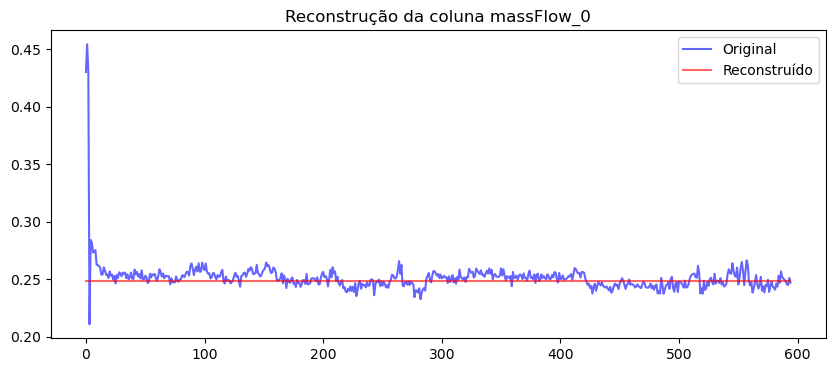

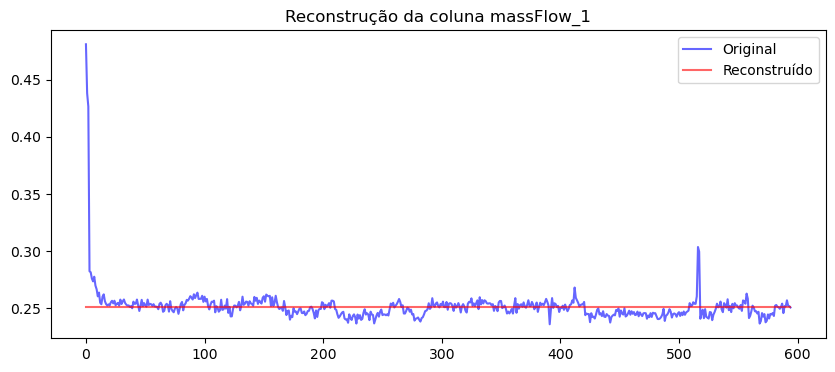

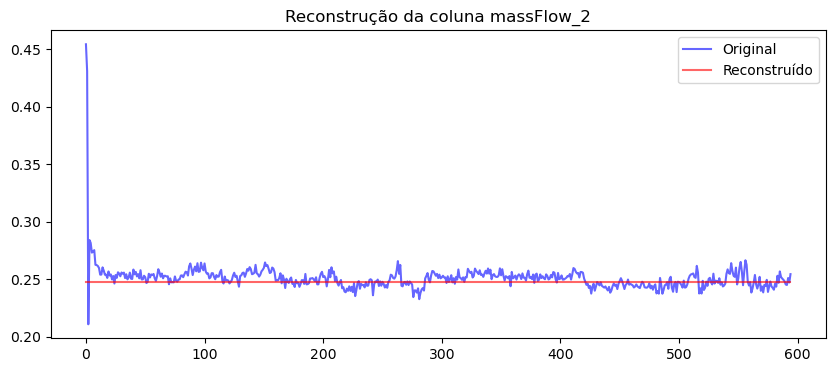

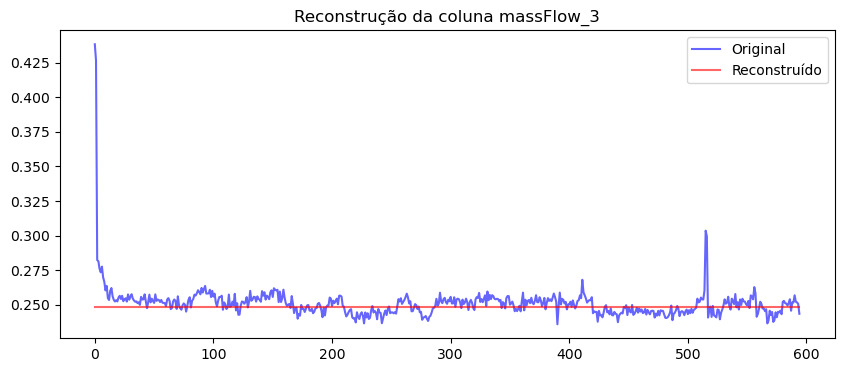

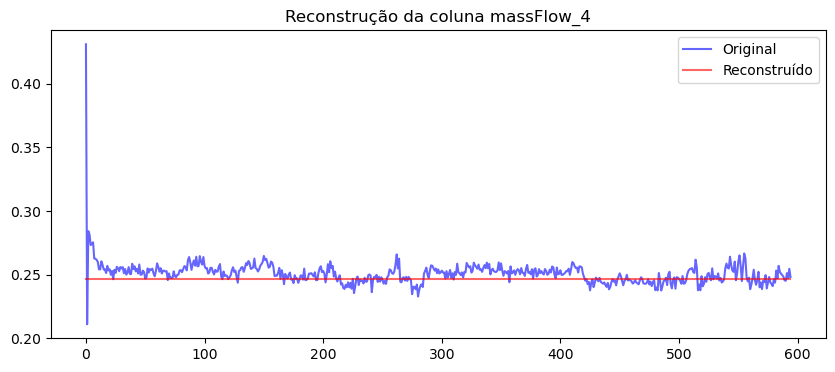

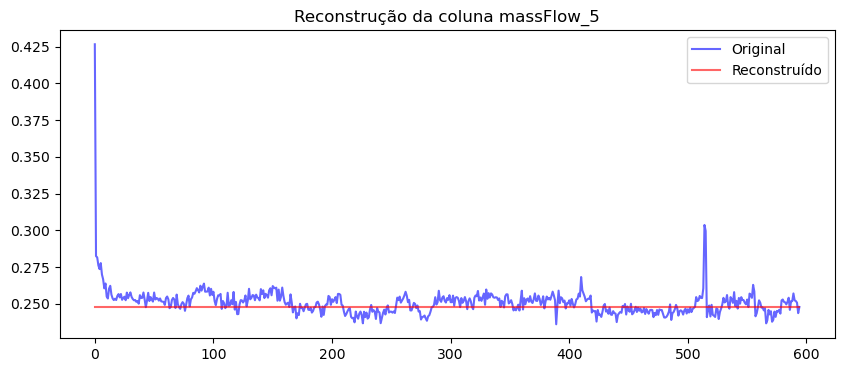

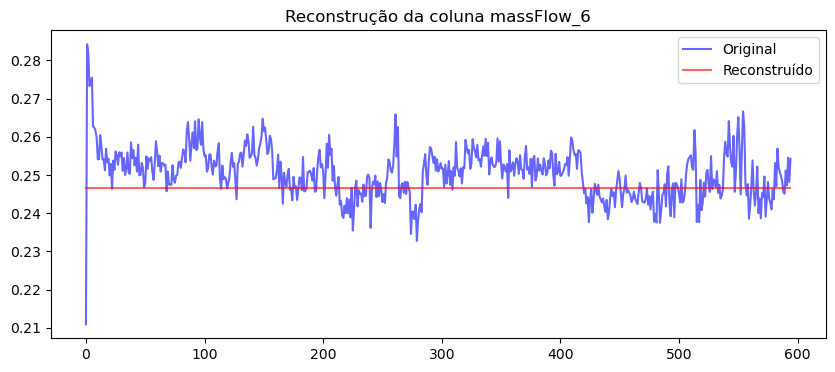

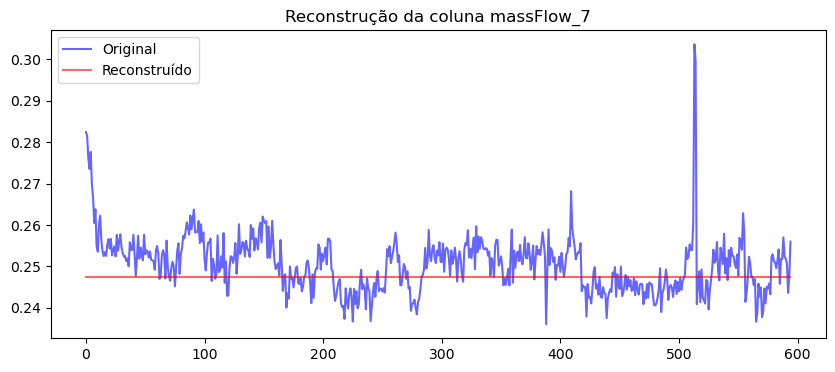

In [27]:
original = x_train_original.numpy()

# Plot para cada feature
for i in range(original.shape[1]):
    plt.figure(figsize=(10, 4))
    plt.plot(original[:, i], label='Original', color='blue', alpha=0.6)
    plt.plot(reconstruido[:, i], label='Reconstruído', color='red', alpha=0.6)
    plt.title(f'Reconstrução da coluna massFlow_{i}')
    plt.legend()
    plt.show()

In [17]:
# Supondo que:
# x_train_original é um tensor PyTorch de formato (amostras, features)
# reconstruido é um array numpy de formato (amostras, features)

# Converter tudo para numpy se necessário
if isinstance(x_train_original, torch.Tensor):
    original_np = x_train_original.numpy()
else:
    original_np = x_train_original

if isinstance(reconstruido, torch.Tensor):
    reconstruido_np = reconstruido.numpy()
else:
    reconstruido_np = reconstruido

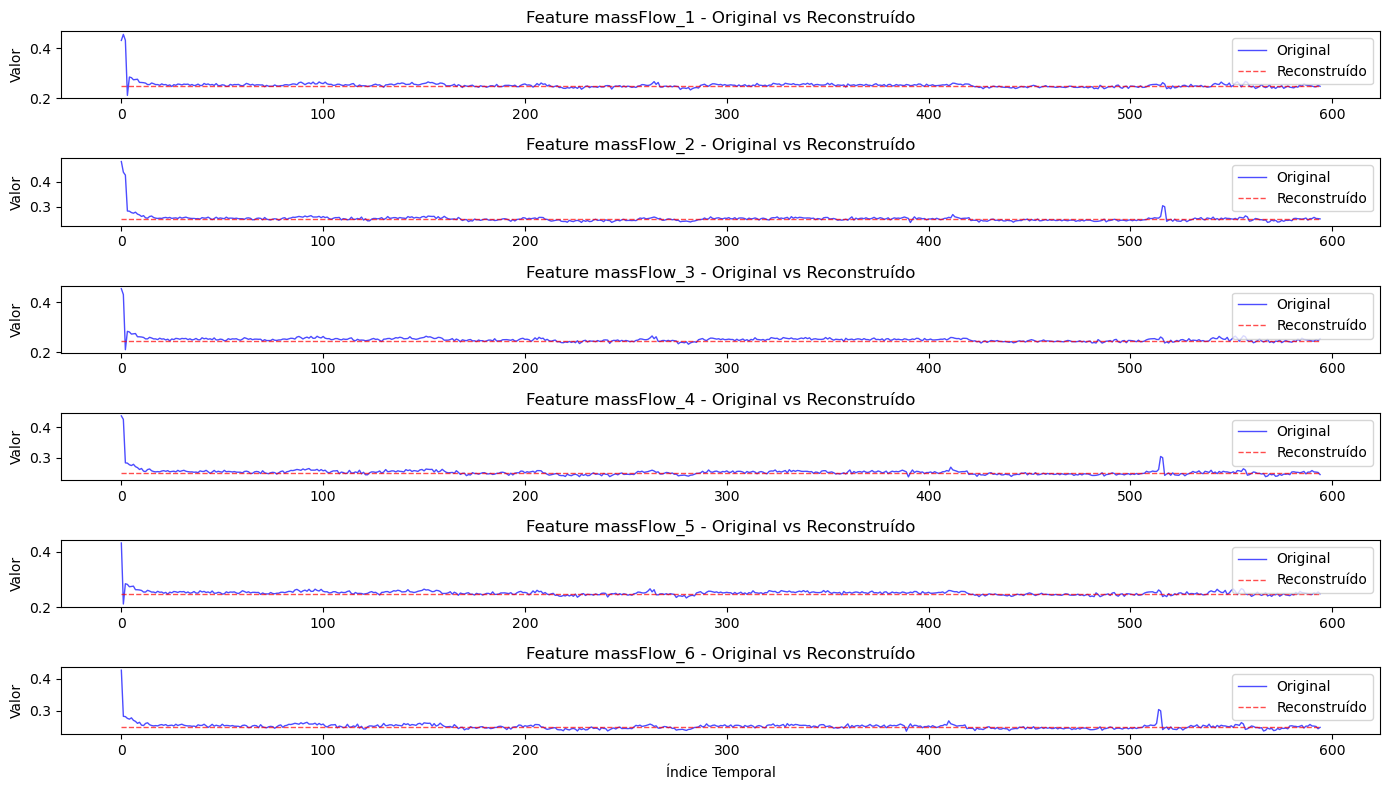

In [18]:
num_features = original_np.shape[1]
time_steps = np.arange(original_np.shape[0])

plt.figure(figsize=(14, 8))

for feature_idx in range(num_features):
    plt.subplot(num_features, 1, feature_idx+1)
    
    # Plot original vs reconstruído para cada feature
    plt.plot(time_steps, original_np[:, feature_idx], 
             'b-', label='Original', alpha=0.7, linewidth=1)
    plt.plot(time_steps, reconstruido_np[:, feature_idx], 
             'r--', label='Reconstruído', alpha=0.7, linewidth=1)
    
    plt.title(f'Feature massFlow_{feature_idx+1} - Original vs Reconstruído')
    plt.ylabel('Valor')
    plt.legend()
    
    if feature_idx == num_features-1:
        plt.xlabel('Índice Temporal')

plt.tight_layout()
plt.show()


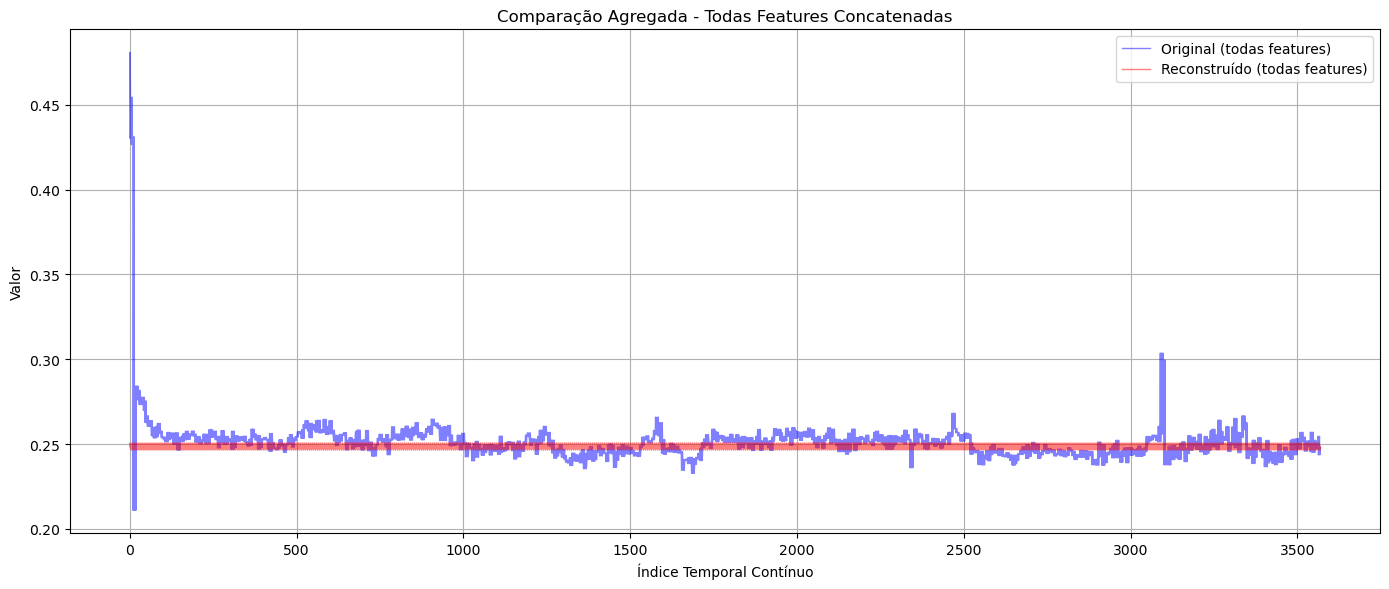

In [19]:
# Plot agregado de todas as features
plt.figure(figsize=(14, 6))

# Concatenar todas as features (achatando o array)
original_flat = original_np.flatten()
reconstruido_flat = reconstruido_np.flatten()
time_steps_flat = np.arange(len(original_flat))

plt.plot(time_steps_flat, original_flat, 
         'b-', label='Original (todas features)', alpha=0.5, linewidth=1)
plt.plot(time_steps_flat, reconstruido_flat, 
         'r-', label='Reconstruído (todas features)', alpha=0.5, linewidth=1)

plt.title('Comparação Agregada - Todas Features Concatenadas')
plt.xlabel('Índice Temporal Contínuo')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:

num_massflows = valor_amostras  # ou o número correto para seu caso##########################################################################
massflow_cols = [f'massFlow_{i}' for i in range(1, num_massflows+1)]
dados_originais = df_original[massflow_cols].values.astype(np.float32)


with torch.no_grad():
    dados_tensor = torch.tensor(dados_originais)
    _, dados_reconstruidos_tensor = model(dados_tensor)
    dados_reconstruidos = dados_reconstruidos_tensor.numpy()


df_reconstruido = df_original.copy()


for i, col in enumerate(massflow_cols):
    df_reconstruido[col] = dados_reconstruidos[:, i]


caminho_saida = "AA_dados_reconstruidos.csv"
df_reconstruido.to_csv(caminho_saida, index=False)

print(f"Arquivo reconstruído salvo em: {caminho_saida}")
print("\nExemplo das primeiras linhas:")
print(df_reconstruido.head())

Arquivo reconstruído salvo em: dados_reconstruidos.csv

Exemplo das primeiras linhas:
   massFlow_1  massFlow_2  massFlow_3  massFlow_4  massFlow_5  massFlow_6  \
0    0.248481    0.251021    0.248067    0.248614    0.246604    0.247594   
1    0.248481    0.251021    0.248067    0.248614    0.246604    0.247594   
2    0.248481    0.251021    0.248067    0.248614    0.246604    0.247594   
3    0.248481    0.251021    0.248067    0.248614    0.246604    0.247594   
4    0.248481    0.251021    0.248067    0.248614    0.246604    0.247594   

   massFlow_7  massFlow_8 anomaly  
0    0.246475     0.24753  n_amac  
1    0.246475     0.24753  n_amac  
2    0.246475     0.24753  n_amac  
3    0.246475     0.24753  n_amac  
4    0.246475     0.24753  n_amac  


In [32]:
amostra_teste = torch.tensor(dados_originais[:1])  # Pega a primeira amostra
with torch.no_grad():
    latent, _ = model(amostra_teste)

dimensao_latente = latent.shape[1]
print(f"Dimensão do espaço latente: {dimensao_latente}")

Dimensão do espaço latente: 4


In [ ]:
with torch.no_grad():
    dados_tensor = torch.tensor(dados_originais)
    latent_representations, _ = model(dados_tensor)
    latent_np = latent_representations.numpy()

# Criar DataFrame com colunas 'massflow_1', 'massflow_2', etc.
df_latent = pd.DataFrame(latent_np, 
                         columns=[f'massFlow_{i+1}' for i in range(latent_np.shape[1])])

# Extrair o label (por exemplo, 'anomaly') e garantir que ele seja a última coluna
label_col = df_original['anomaly'].reset_index(drop=True)  # Ajustar se o nome do label for diferente
df_latent['anomaly'] = label_col

# Salvar o DataFrame
caminho_latente = "AA_espaco_latente.csv"
df_latent.to_csv(caminho_latente, index=False)

print(f"\nArquivo do espaço latente salvo em: {caminho_latente}")
print("\nExemplo da estrutura:")
print(df_latent.head())


Arquivo do espaço latente salvo em: espaco_latente.csv

Exemplo da estrutura:
   massFlow_1  massFlow_2  massFlow_3  massFlow_4 anomaly
0    0.234943    0.862244   -0.027334    0.314671  n_amac
1    0.298909    0.866674   -0.070894    0.329629  n_amac
2    0.443976    0.901131   -0.160795    0.364179  n_amac
3    0.818361    1.059595   -0.283099    0.430263  n_amac
4    0.749133    1.028514   -0.260700    0.416967  n_amac
